In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import cv2
import numpy as np

data_path = "/content/drive/MyDrive/gt_db"
image_size = (100, 100)

faces = []
labels = []
paths = []
label_map = {}

label_id = 0

for person_name in sorted(os.listdir(data_path)):
    person_path = os.path.join(data_path, person_name)

    if not os.path.isdir(person_path):
        continue

    label_map[label_id] = person_name

    for img_name in sorted(os.listdir(person_path)):
        img_path = os.path.join(person_path, img_name)

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img = cv2.resize(img, image_size)
        img = img / 255.0   # normalization

        faces.append(img.flatten())
        labels.append(label_id)
        paths.append(img_path)

    label_id += 1

faces = np.array(faces)
labels = np.array(labels)
paths = np.array(paths)

print("Total images:", faces.shape)

Total images: (750, 10000)


In [6]:
import random

X_train, X_test = [], []
y_train, y_test = [], []
train_paths, test_paths = [], []

random.seed(42)

for label in np.unique(labels):
    idx = np.where(labels == label)[0]

    idx = list(idx)
    random.shuffle(idx)

    split = 12   # FIXED: 12 train, 3 test

    train_idx = idx[:split]
    test_idx = idx[split:]

    for i in train_idx:
        X_train.append(faces[i])
        y_train.append(labels[i])
        train_paths.append(paths[i])

    for i in test_idx:
        X_test.append(faces[i])
        y_test.append(labels[i])
        test_paths.append(paths[i])

X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (600, 10000)
Test: (150, 10000)


In [13]:
from sklearn.decomposition import PCA

n_components = 60   # SAFE choice (prevents overfitting)

pca = PCA(n_components=n_components, whiten=True)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_pca, y_train)

KNeighborsClassifier(n_neighbors=3)

In [15]:
from sklearn.metrics import accuracy_score

train_acc = knn.score(X_train_pca, y_train)
test_acc = knn.score(X_test_pca, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)

Train Accuracy: 0.99
Test Accuracy: 0.9666666666666667


In [16]:
from sklearn.metrics import classification_report

y_pred = knn.predict(X_test_pca)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         3
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         3
          13       0.75      1.00      0.86         3
          14       1.00      1.00      1.00         3
          15       1.00      1.00      1.00         3
          16       1.00      1.00      1.00         3
          17       1.00    

In [18]:
for i in range(5):
    print("Image:", test_paths[i])
    print("Actual:", label_map[y_test[i]])
    print("Predicted:", label_map[y_pred[i]])
    print("-" * 40)

Image: /content/drive/MyDrive/gt_db/s01/01.jpg
Actual: s01
Predicted: s46
----------------------------------------
Image: /content/drive/MyDrive/gt_db/s01/02.jpg
Actual: s01
Predicted: s01
----------------------------------------
Image: /content/drive/MyDrive/gt_db/s01/11.jpg
Actual: s01
Predicted: s01
----------------------------------------
Image: /content/drive/MyDrive/gt_db/s02/02.jpg
Actual: s02
Predicted: s02
----------------------------------------
Image: /content/drive/MyDrive/gt_db/s02/15.jpg
Actual: s02
Predicted: s02
----------------------------------------


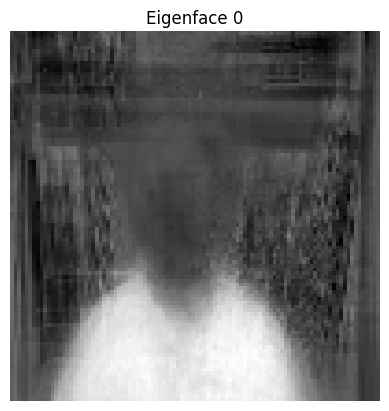

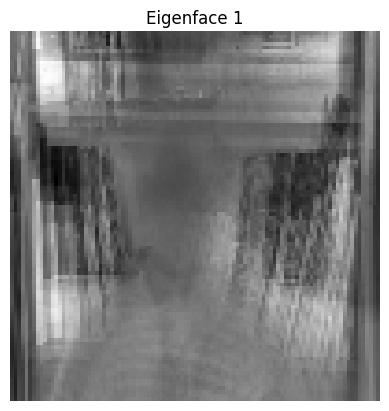

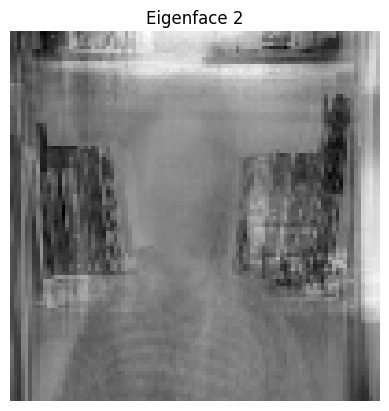

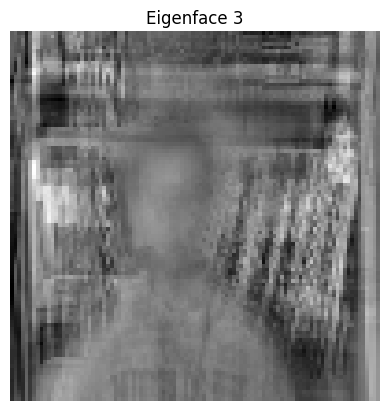

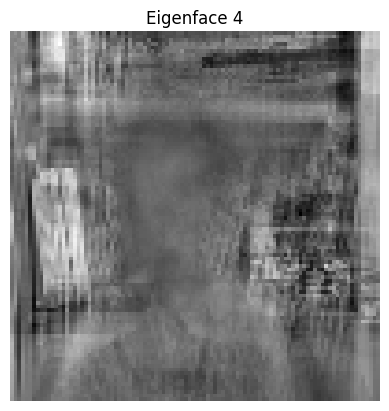

In [19]:
import matplotlib.pyplot as plt

eigenfaces = pca.components_.reshape((n_components, 100, 100))

for i in range(5):
    plt.imshow(eigenfaces[i], cmap='gray')
    plt.title(f"Eigenface {i}")
    plt.axis('off')
    plt.show()

In [20]:
import os

base_path = "/content/drive/MyDrive/face_recognition_pca"
model_path = os.path.join(base_path, "model")
data_path = os.path.join(base_path, "data")

os.makedirs(model_path, exist_ok=True)
os.makedirs(data_path, exist_ok=True)

print("Folders created")

Folders created


In [21]:
import pickle
import json

# PCA
with open(os.path.join(model_path, "pca_model.pkl"), "wb") as f:
    pickle.dump(pca, f)

# KNN
with open(os.path.join(model_path, "knn_model.pkl"), "wb") as f:
    pickle.dump(knn, f)

# label map
with open(os.path.join(model_path, "label_map.json"), "w") as f:
    json.dump(label_map, f)


with open(os.path.join(model_path, "image_size.json"), "w") as f:
    json.dump({"image_size": image_size}, f)

In [22]:
import numpy as np
import json


np.save(os.path.join(data_path, "X_train.npy"), X_train)
np.save(os.path.join(data_path, "y_train.npy"), y_train)

np.save(os.path.join(data_path, "X_test.npy"), X_test)
np.save(os.path.join(data_path, "y_test.npy"), y_test)


with open(os.path.join(data_path, "train_paths.json"), "w") as f:
    json.dump(train_paths, f)

with open(os.path.join(data_path, "test_paths.json"), "w") as f:
    json.dump(test_paths, f)

print("All data saved successfully")

All data saved successfully
